In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# TensorFlow Datasets에서 'cats_vs_dogs' 로드 (이미지와 라벨 포함)
(train_ds, val_ds) = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True
)

# 전처리 함수 정의
def preprocess(image, label):
    image = tf.image.resize(image, (160, 160))
    image = tf.cast(image, tf.float32) / 255.0  # 정규화
    return image, label

train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.C3GVTI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [2]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False  # 사전학습된 가중치 고정

model_A = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model A (Transfer Learning)...")
history_A = model_A.fit(train_ds, validation_data=val_ds, epochs=5)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Model A (Transfer Learning)...
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 73s 95ms/step - accuracy: 0.9635 - loss: 0.0967 - val_accuracy: 0.9791 - val_loss: 0.0628
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.9789 - loss: 0.0587 - val_accuracy: 0.9791 - val_loss: 0.0590
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.9815 - loss: 0.0524 - val_accuracy: 0.9798 - val_loss: 0.0585
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.9837 - loss: 0.0484 - val_accuracy: 0.9809 - val_loss: 0.0587
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9850 - loss: 0.0453 - val_accuracy: 0.9804 - val_loss: 0.0592


In [3]:
model_B = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(160, 160, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Training Model B (From Scratch)...")
history_B = model_B.fit(train_ds, validation_data=val_ds, epochs=10)


Training Model B (From Scratch)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 56ms/step - accuracy: 0.6726 - loss: 0.5912 - val_accuracy: 0.7440 - val_loss: 0.5156
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.7810 - loss: 0.4621 - val_accuracy: 0.7919 - val_loss: 0.4497
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8279 - loss: 0.3793 - val_accuracy: 0.7829 - val_loss: 0.4799
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.8716 - loss: 0.2992 - val_accuracy: 0.7831 - val_loss: 0.5408
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.9053 - loss: 0.2216 - val_accuracy: 0.7717 - val_loss: 0.6916
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9302 - loss: 0.1748 - val_accuracy: 0.7973 - val_loss: 0.6456
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9571 - loss: 0.1136 - val_accuracy: 0.7880 - val_loss: 0.7937
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.9731 - loss: 0.0767 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


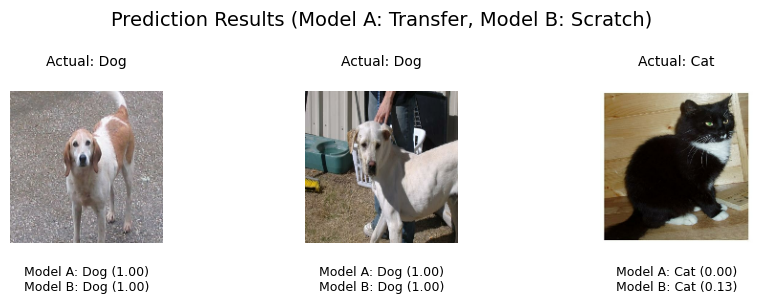

In [4]:
# 무작위 샘플 3장 선택
sample_images = list(val_ds.unbatch().shuffle(1000).take(3))

# 시각화용 설정
fig, axes = plt.subplots(1, 3, figsize=(9, 3))  # 사진 3개를 가로로 한번에 보기 위한 구성
fig.suptitle("Prediction Results (Model A: Transfer, Model B: Scratch)", fontsize=14)

# 클래스 이름
class_names = ['Cat', 'Dog']

# 3개 이미지 반복 처리
for i, (image, label) in enumerate(sample_images):
    img_array = tf.expand_dims(image, axis=0)
    true_label = int(label.numpy())

    # 모델 A 예측
    pred_prob_A = model_A.predict(img_array)[0][0]
    pred_label_A = int(pred_prob_A > 0.5)

    # 모델 B 예측
    pred_prob_B = model_B.predict(img_array)[0][0]
    pred_label_B = int(pred_prob_B > 0.5)

    # 이미지 표시
    ax = axes[i]
    ax.imshow(image.numpy())
    ax.axis('off')

    # 제목 및 예측 결과 표시
    ax.set_title(f"Actual: {class_names[true_label]}\n", fontsize=10)

    # 하단에 예측 결과를 표 형태로 표시
    ax.text(0.5, -0.15,
            f"Model A: {class_names[pred_label_A]} ({pred_prob_A:.2f})\n"
            f"Model B: {class_names[pred_label_B]} ({pred_prob_B:.2f})",
            fontsize=9, ha='center', va='top', transform=ax.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # 제목 공간 확보
plt.show()


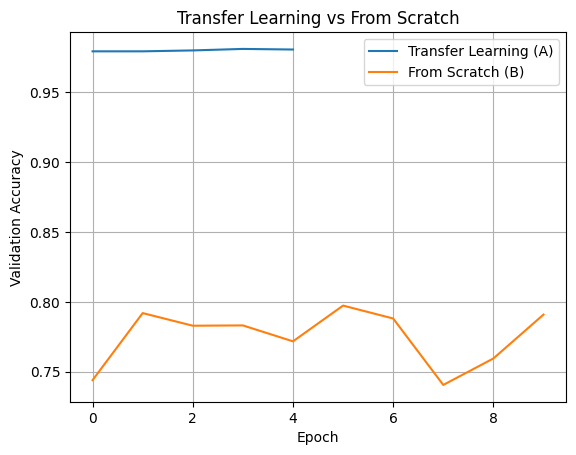

In [5]:
plt.plot(history_A.history['val_accuracy'], label='Transfer Learning (A)')
plt.plot(history_B.history['val_accuracy'], label='From Scratch (B)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Transfer Learning vs From Scratch')
plt.legend()
plt.grid(True)
plt.show()
